# **CS4850 - Data Mining**
#### Student: Shobanapriyan Chandrasegaran
#### Student ID: 240248516
#### Programme: MSC Applied Artificial Intelligence

## 1.Exploratory Data Analysis and Data Pre-processing
This notebook presents a comprehensive exploration and preparation of the dataset prior to model development. The Exploratory Data Analysis (EDA) focuses on understanding the underlying structure and characteristics of the data. Key tasks include examining the total number of features, identifying their data types, and detecting the presence of missing values and outliers. Additionally, a statistical summary of features is provided to gain insights into distributions, central tendencies, and variability.

Based on the findings from the EDA, appropriate data pre-processing techniques are applied to ensure data quality and improve model performance. For missing value handling, a simple imputation strategy is used to fill in missing entries. Outliers are identified using the Interquartile Range (IQR) method, and corresponding values are treated using imputation to maintain data consistency. To address potential high dimensionality and multicollinearity among features, Principal Component Analysis (PCA) is performed. This not only reduces the number of features but also aids in extracting the most informative components, preserving as much variance as possible.

In [108]:
# !pip install pandas
# !pip install numpy
# !pip install sklearn
# !pip install matplotlib
# !pip install seaborn
# !pip install missingno
# !pip install xgboost
# !pip install imbalanced-learn

In [1]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import itertools
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter

In [2]:
# Load the dataset
df = pd.read_csv('../df/df.csv')
print(len(df))

45000


In [8]:
df.head(10)

,Info_PepID,Info_organism_id,Info_protein_id,Info_pos,Info_AA,Info_epitope_id,Info_nPos,Info_nNeg,Info_cluster,Class,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,XP_805308.1:48,5693,XP_805308.1,1798,K,361766,0,1,50,1,...,-0.468073,0.116790,0.807796,-0.017825,0.319631,0.440370,0.160651,0.187754,-0.009569,-0.148201
1,XP_820569.1:60,5693,XP_820569.1,1322,T,"406333,251535","0,0","1,1",263,1,...,-0.088303,0.242516,0.351394,0.108301,0.058621,0.035160,-0.285763,-0.031222,-0.022093,-0.066371
2,XP_815900.1:8,5693,XP_815900.1,149,R,285339,0,1,197,1,...,0.121043,0.248497,0.388882,-0.257999,-0.532345,0.043773,-0.496472,0.082051,0.516216,0.131131
3,XP_821138.1:10,5693,XP_821138.1,187,E,"396765,346179","0,0","1,1",270,1,...,-0.039452,0.102934,0.039270,0.305421,0.069568,-0.207785,-0.155033,0.177424,-0.191218,-0.144111
4,XP_804893.1:6,5693,XP_804893.1,113,T,"307209,417548,272283","0,0,0","1,1,1",39,1,...,-0.074366,0.182009,0.374801,0.150980,0.063649,0.251235,-0.217734,-0.070261,NaN,0.108773
5,XP_818927.1:8,5693,XP_818927.1,153,K,"285165,317308","0,0","1,1",239,1,...,-0.077776,1.118993,-0.025805,-0.179897,0.104518,0.500418,-0.565767,0.210139,0.243640,0.221370
6,XP_815841.1:14,5693,XP_815841.1,238,Q,361097,0,1,195,1,...,0.058188,0.334426,0.033269,0.541409,0.011510,0.122834,-0.460149,0.162810,-0.098404,0.192424
7,XP_810047.1:2,5693,XP_810047.1,58,Q,352152,0,1,126,1,...,-0.043750,0.217299,0.615541,-0.335398,-0.050057,0.209456,-0.352427,-0.185083,0.439084,0.370860
8,XP_816335.1:207,5693,XP_816335.1,4480,G,"338490,297580","0,0","1,1",205,1,...,-0.175965,0.195719,-0.008945,0.010798,0.305106,-0.435959,-0.262463,-0.067981,0.027540,0.116307
9,XP_807041.1:6,5693,XP_807041.1,149,Q,"316698,383025","0,0","1,1",82,1,...,-0.028591,0.366822,0.243247,-0.141986,-0.132534,0.428441,-0.476763,0.234515,-0.028257,-0.029350


#### 1.1 Group-by counts of distinct Info clusters

In [3]:
df["Info_cluster"].value_counts()

Info_cluster
205    1302
154    1105
153     761
211     660
44      636
       ... 
227      17
233      17
238      17
19       13
253      12
Name: count, Length: 265, dtype: int64

#### 1.2 Find the number range of info clusters

In [4]:
values = []
count=0
for val, count_val in df["Info_cluster"].value_counts().items():
    values.append(val)
    # print(f"value {val} : count {count_val}")

for i in range(7,284):
    if i not in values:
        print(i)

40
83
97
98
99
100
255
256
257
258
259
260


#### 1.3 Check the feature columns are having NAN values 

In [5]:
df.describe()

,Info_organism_id,Info_pos,Info_cluster,Class,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
count,45000.0,45000.000000,45000.000000,45000.000000,44875.000000,44877.000000,44878.000000,44878.000000,44875.000000,44879.000000,...,44880.000000,44880.000000,44880.000000,44877.000000,44883.000000,44878.000000,44879.000000,44876.000000,44877.000000,44878.000000
mean,5693.0,447.296089,139.654600,0.967200,-0.039606,0.160049,0.017938,-0.057273,0.028865,0.021685,...,-0.110613,0.251669,0.307180,0.008672,-0.000748,0.075752,-0.207077,0.002944,0.156875,0.042213
std,0.0,644.610448,77.503943,0.254019,0.217937,0.235235,0.223697,0.203302,0.191072,0.233649,...,0.185992,0.224936,0.246561,0.228126,0.214728,0.193606,0.214950,0.215770,0.242130,0.168709
min,5693.0,1.000000,7.000000,-1.000000,-1.227230,-1.007699,-1.013036,-1.084318,-1.083190,-0.992769,...,-1.200947,-0.863942,-0.840178,-0.955090,-0.801058,-1.259941,-1.353211,-1.011878,-0.870440,-1.363285
25%,5693.0,127.000000,70.000000,1.000000,-0.170128,0.009085,-0.139578,-0.189086,-0.085854,-0.140332,...,-0.225446,0.127749,0.159726,-0.149679,-0.138328,-0.042319,-0.341363,-0.142277,-0.015918,-0.055819
50%,5693.0,252.000000,144.000000,1.000000,-0.036407,0.166322,0.011868,-0.057180,0.036239,0.022239,...,-0.105319,0.248071,0.323067,0.016748,-0.003804,0.071618,-0.214813,-0.011618,0.141990,0.051576
75%,5693.0,463.000000,205.000000,1.000000,0.095783,0.325098,0.176197,0.071387,0.153798,0.181753,...,0.010166,0.368981,0.479612,0.165347,0.131464,0.185427,-0.078609,0.126861,0.327906,0.150610
max,5693.0,4841.000000,283.000000,1.000000,1.005142,0.906993,1.093170,0.964590,1.125806,1.098894,...,0.984308,1.591331,1.436569,1.216748,1.385962,1.290139,0.863799,1.206357,1.212296,0.700200


Insight gained:

The  number of none value records are less than total records , which mean feature columns are having missing values 

### 1.4 Remove all the duplicate records 

In [6]:
df = df.drop_duplicates()

In [7]:
print(len(df))

45000


### 1.5 Isolate the feature variables for EDA

In [9]:
df_features = df.iloc[:, 10:]

In [10]:
df_features.head(10)

,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,feat_esm1b_6,feat_esm1b_7,feat_esm1b_8,feat_esm1b_9,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,0.102583,0.014834,-0.029821,-0.531718,-0.300513,0.432465,0.088331,-0.088768,0.509410,-0.322485,...,-0.468073,0.116790,0.807796,-0.017825,0.319631,0.440370,0.160651,0.187754,-0.009569,-0.148201
1,-0.183578,-0.023078,0.297570,-0.280538,-0.015743,0.356715,-0.243509,0.324504,0.057052,0.163628,...,-0.088303,0.242516,0.351394,0.108301,0.058621,0.035160,-0.285763,-0.031222,-0.022093,-0.066371
2,-0.318074,0.258911,-0.373156,-0.122325,-0.003030,0.017651,0.403156,0.121330,-0.170907,-0.571392,...,0.121043,0.248497,0.388882,-0.257999,-0.532345,0.043773,-0.496472,0.082051,0.516216,0.131131
3,0.256412,0.052065,-0.209717,-0.360065,0.057306,0.232716,-0.261893,0.068935,0.160946,0.099433,...,-0.039452,0.102934,0.039270,0.305421,0.069568,-0.207785,-0.155033,0.177424,-0.191218,-0.144111
4,-0.369158,0.329947,0.210204,-0.151422,-0.053231,0.509926,-0.264485,0.275772,-0.070120,0.353799,...,-0.074366,0.182009,0.374801,0.150980,0.063649,0.251235,-0.217734,-0.070261,NaN,0.108773
5,-0.047258,0.298683,-0.322268,-0.205748,-0.369228,0.417361,0.070378,-0.242832,-0.131637,-0.408601,...,-0.077776,1.118993,-0.025805,-0.179897,0.104518,0.500418,-0.565767,0.210139,0.243640,0.221370
6,-0.194665,-0.049634,0.043487,0.088648,0.185729,0.054151,-0.236219,0.029712,0.165890,-0.018852,...,0.058188,0.334426,0.033269,0.541409,0.011510,0.122834,-0.460149,0.162810,-0.098404,0.192424
7,-0.212324,0.167634,-0.113703,-0.132624,0.140996,-0.208226,-0.091920,0.302694,0.131339,-0.308968,...,-0.043750,0.217299,0.615541,-0.335398,-0.050057,0.209456,-0.352427,-0.185083,0.439084,0.370860
8,-0.251997,0.165570,0.264857,0.133415,0.077018,0.339979,-0.418949,0.356945,-0.052183,-0.265755,...,-0.175965,0.195719,-0.008945,0.010798,0.305106,-0.435959,-0.262463,-0.067981,0.027540,0.116307
9,-0.083419,-0.000945,0.066354,0.111320,-0.127441,-0.005077,-0.099683,0.111710,-0.052914,0.024520,...,-0.028591,0.366822,0.243247,-0.141986,-0.132534,0.428441,-0.476763,0.234515,-0.028257,-0.029350


#### 1.6 Analyse data types for each columns

In [11]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Columns: 1280 entries, feat_esm1b_0 to feat_esm1b_1279
dtypes: float64(1280)
memory usage: 439.5 MB


In [12]:
df_features['feat_esm1b_1001'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 45000 entries, 0 to 44999
Series name: feat_esm1b_1001
Non-Null Count  Dtype  
--------------  -----  
44878 non-null  float64
dtypes: float64(1)
memory usage: 351.7 KB


Insight gained:

The  all the feature columns are belongs to same data type float64, and there is no data consistency. 

### 1.7 Analyse missing values

In [13]:
missing_summary = df_features.isnull().sum()
print(missing_summary)

feat_esm1b_0       125
feat_esm1b_1       123
feat_esm1b_2       122
feat_esm1b_3       122
feat_esm1b_4       125
                  ... 
feat_esm1b_1275    122
feat_esm1b_1276    121
feat_esm1b_1277    124
feat_esm1b_1278    123
feat_esm1b_1279    122
Length: 1280, dtype: int64


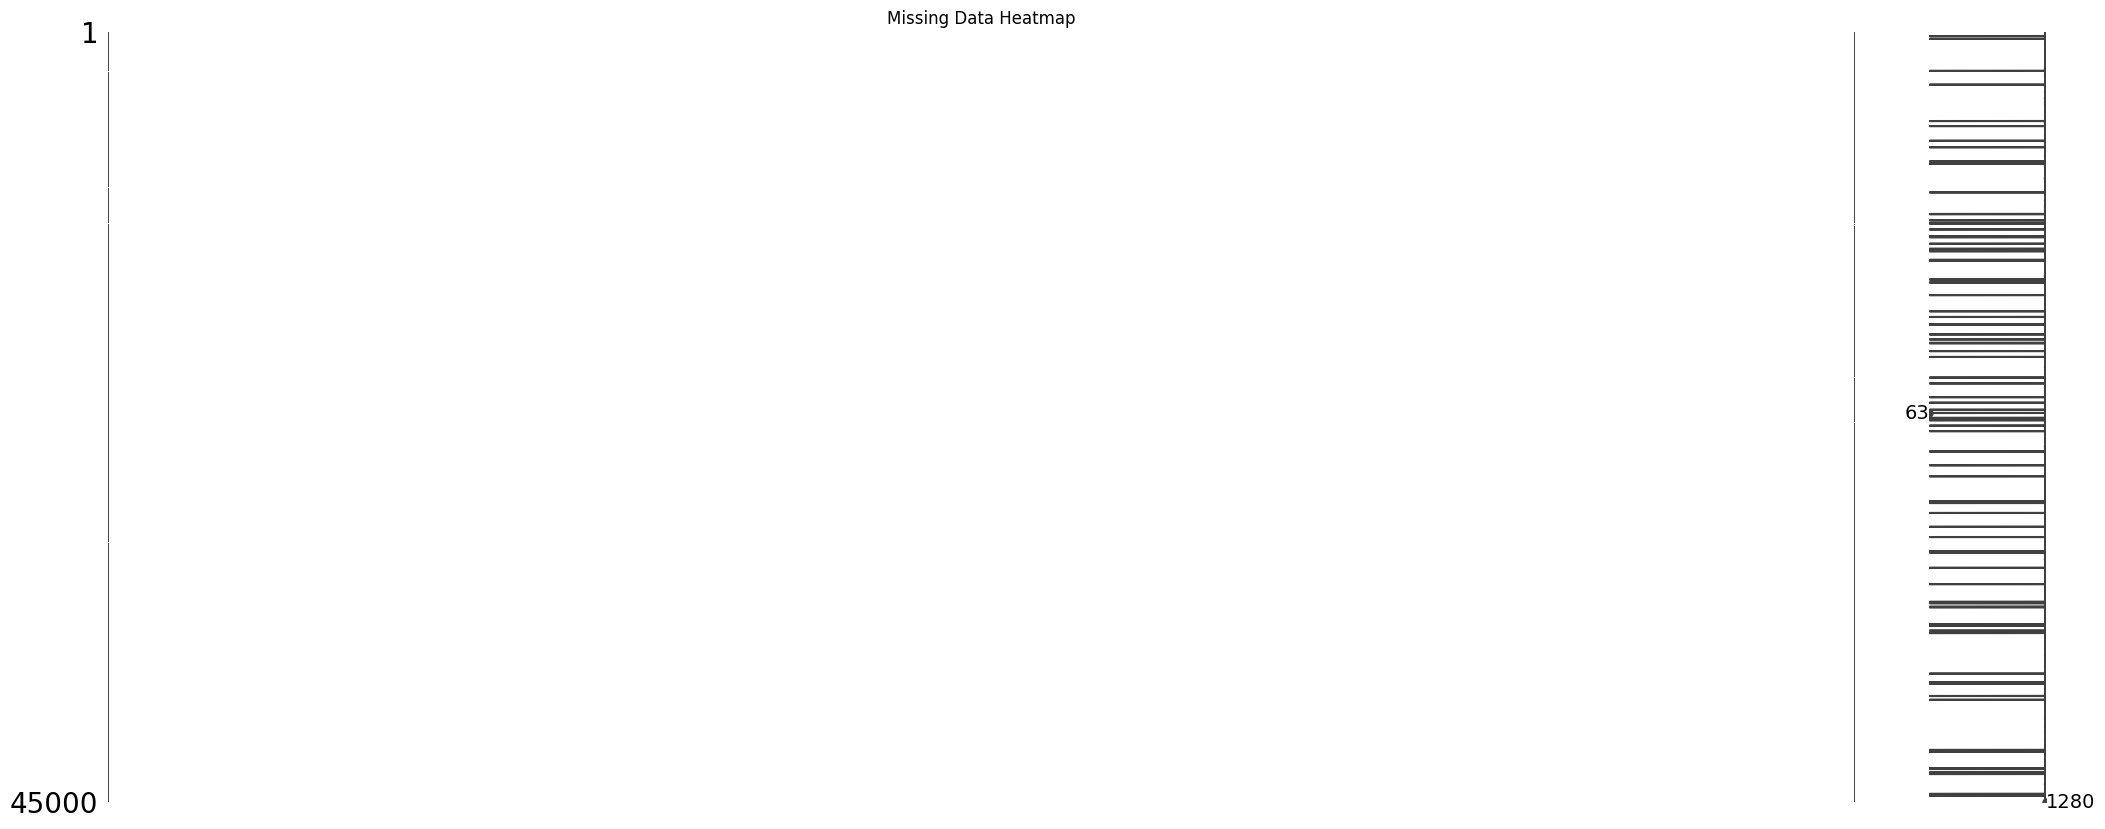

In [14]:
msno.matrix(df_features)
plt.title('Missing Data Heatmap')
plt.show()

### 1.8 Remove missing values using simple mean impute

In [15]:
imputer = SimpleImputer(strategy='mean') 
df_features_no_missing_values = pd.DataFrame(imputer.fit_transform(df_features), columns=df_features.columns)

### 1.9 Handle Outliers - simple imputation

In [16]:
def detect_outliers_iqr(df, column, threshold=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(len(outliers))
    return outliers

def simple_imputation(df, column):
    # Step 1: Detect outliers
    outliers = detect_outliers_iqr(df, column)
    outlier_indices = outliers.index
    
    if len(outlier_indices) == 0:
        return df  # No outliers to impute
    
    # Step 2: Mark outliers as NaN
    df_temp = df.copy()
    df_temp.loc[outlier_indices, column] = np.nan
    
    # Step 3: Impute using simple imputer
    imputer = SimpleImputer(strategy='mean') 
    imputed_values = imputer.fit_transform(df_temp[[column]])  # Returns 2D array (rows, 1)
    
    # Step 4: Flatten to 1D and map indices correctly
    imputed_values_flat = imputed_values[:, 0]  # Convert to 1D array
    
    # Get integer positions of outlier indices in the DataFrame
    outlier_positions = df_temp.index.get_indexer(outlier_indices)
    
    # Replace outliers in the original DataFrame
    df.loc[outlier_indices, column] = imputed_values_flat[outlier_positions]
    
    return df

columns = df_features_no_missing_values.columns

df_features_no_outliers = df_features_no_missing_values.copy()
for ele in columns:
    df_features_tem = simple_imputation(df_features_no_outliers, ele)
    df_features_no_outliers = df_features_tem
    print(f"imputation complted for {ele}")

1179
imputation complted for feat_esm1b_0
388
imputation complted for feat_esm1b_1
229
imputation complted for feat_esm1b_2
702
imputation complted for feat_esm1b_3
962
imputation complted for feat_esm1b_4
260
imputation complted for feat_esm1b_5
587
imputation complted for feat_esm1b_6
817
imputation complted for feat_esm1b_7
1160
imputation complted for feat_esm1b_8
910
imputation complted for feat_esm1b_9
1203
imputation complted for feat_esm1b_10
1377
imputation complted for feat_esm1b_11
804
imputation complted for feat_esm1b_12
783
imputation complted for feat_esm1b_13
776
imputation complted for feat_esm1b_14
142
imputation complted for feat_esm1b_15
763
imputation complted for feat_esm1b_16
892
imputation complted for feat_esm1b_17
264
imputation complted for feat_esm1b_18
1263
imputation complted for feat_esm1b_19
642
imputation complted for feat_esm1b_20
52
imputation complted for feat_esm1b_21
1652
imputation complted for feat_esm1b_22
1509
imputation complted for feat_esm1b

#### 1.10 Dimensionality Reduction Techniques: Principal Component Analysis (PCA)

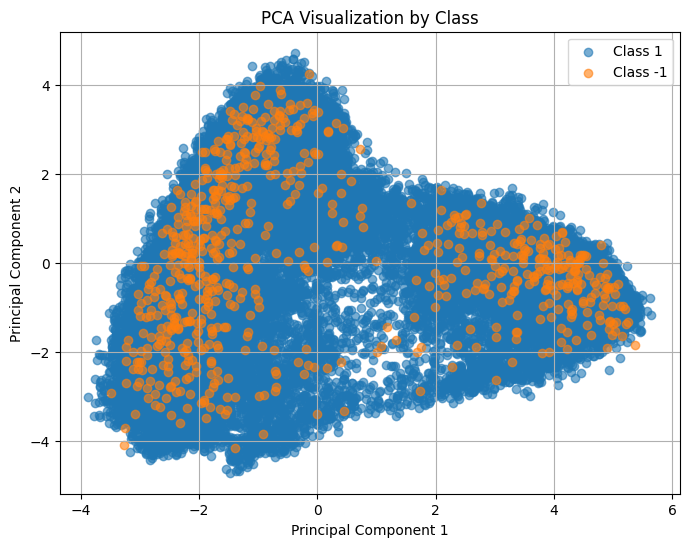

In [17]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_features_no_outliers)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Class'] = df['Class'].values

# Plot
plt.figure(figsize=(8, 6))
for label in pca_df['Class'].unique():
    subset = pca_df[pca_df['Class'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Class {label}', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization by Class')
plt.legend()
plt.grid(True)
plt.show()

#### 1.11 Box plot for principle components

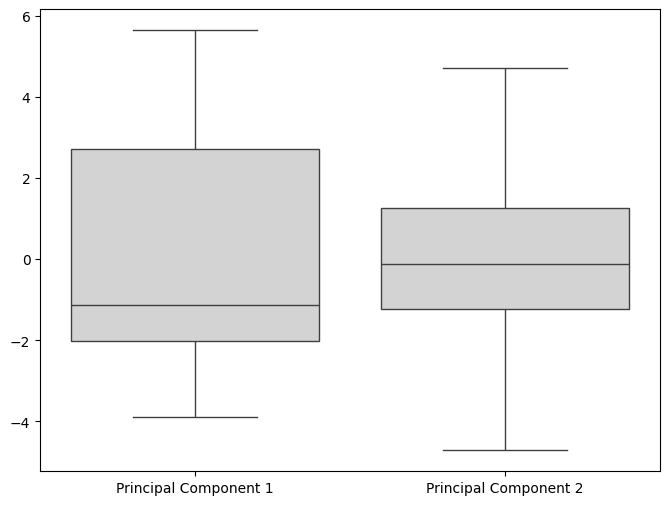

In [18]:
# Assuming principal_components has been computed
pca_df = pd.DataFrame(principal_components, columns=['Principal Component 1', 'Principal Component 2'])

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=pca_df, color='lightgray')

# Show the plot
plt.show()


Insight gained: 

There are no ouliers in the 2 dimensional space of the feature vectors.

#### 1.12 Correlation coefficients between pairs of features, aiding in the detection of highly correlated attributes

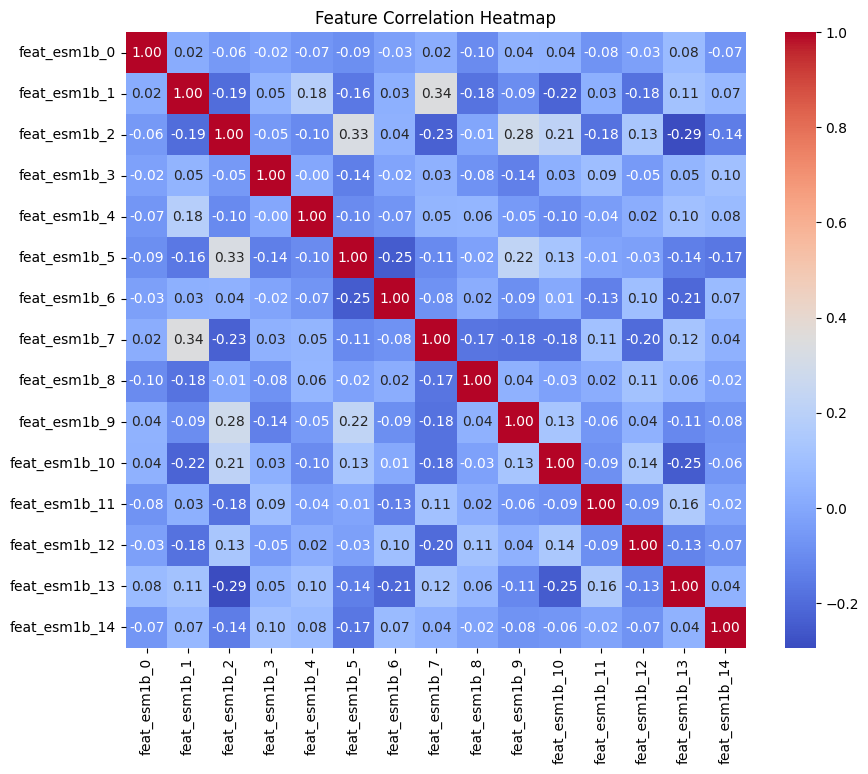

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_df = df_features_no_outliers.iloc[:, :15]
corr = selected_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

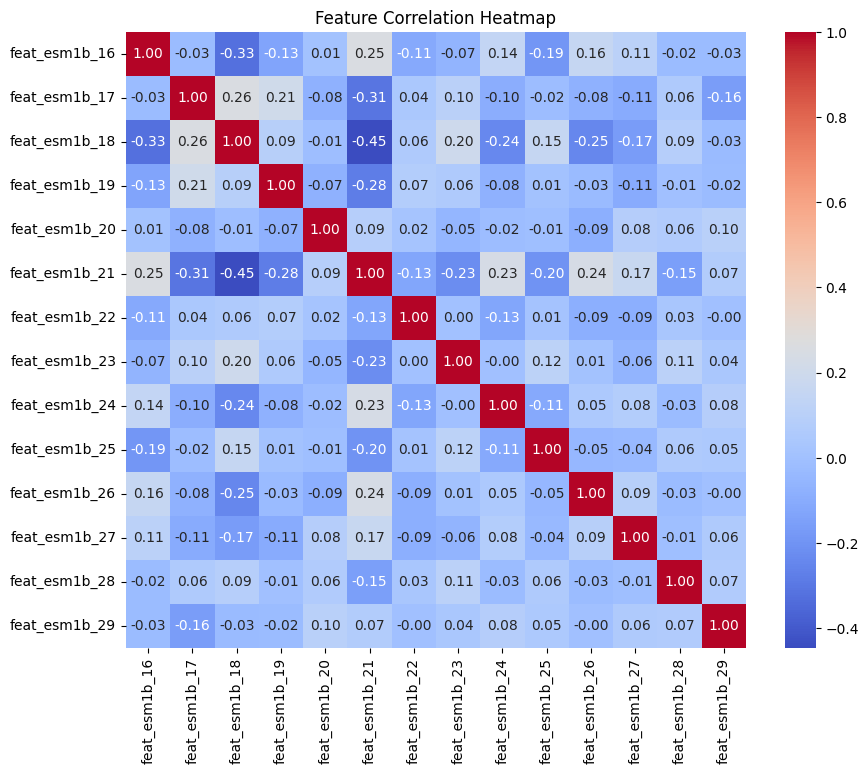

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_df = df_features_no_outliers.iloc[:, 16:30]
corr = selected_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Gained insights:

There are notable variables highly correlated to each others. 
Eg : feat_1 & feat_7 (0.34)

#### 1.13 Data imbalance check

In [21]:
df["Class"].value_counts()

Class
 1    44262
-1      738
Name: count, dtype: int64

Gained insights :
The given dataset is imbalanced.

#### 1.14 Merge the df_features with df["cluster_info"] column after all EDA completion

In [129]:
df_features_no_outliers.head()

,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,feat_esm1b_6,feat_esm1b_7,feat_esm1b_8,feat_esm1b_9,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,0.102583,0.014834,-0.029821,-0.531718,-0.300513,0.432465,0.088331,-0.088768,-0.014903,-0.322485,...,-0.468073,0.116790,0.807796,-0.017825,0.319631,0.440370,0.160651,0.187754,-0.009569,-0.148201
1,-0.183578,-0.023078,0.297570,-0.280538,-0.015743,0.356715,-0.243509,0.324504,0.057052,0.163628,...,-0.088303,0.242516,0.351394,0.108301,0.058621,0.035160,-0.285763,-0.031222,-0.022093,-0.066371
2,-0.318074,0.258911,-0.373156,-0.122325,-0.003030,0.017651,0.403156,0.121330,-0.170907,-0.571392,...,0.121043,0.248497,0.388882,-0.257999,-0.532345,0.043773,-0.496472,0.082051,0.516216,0.131131
3,0.256412,0.052065,-0.209717,-0.360065,0.057306,0.232716,-0.261893,0.068935,0.160946,0.099433,...,-0.039452,0.102934,0.039270,0.305421,0.069568,-0.207785,-0.155033,0.177424,-0.191218,-0.144111
4,-0.369158,0.329947,0.210204,-0.151422,-0.053231,0.509926,-0.264485,0.275772,-0.070120,0.353799,...,-0.074366,0.182009,0.374801,0.150980,0.063649,0.251235,-0.217734,-0.070261,0.156875,0.108773


In [22]:
df["Info_cluster"].head()

0     50
1    263
2    197
3    270
4     39
Name: Info_cluster, dtype: int64

In [23]:
# Combine "Info_cluster" from df with df_features_no_outliers
df_features_no_outliers_with_cluster_info = pd.concat(
    [df["Info_cluster"].loc[df_features_no_outliers.index], df_features_no_outliers],
    axis=1
)

In [24]:
df_features_no_outliers_with_cluster_info.head(10)

,Info_cluster,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,feat_esm1b_6,feat_esm1b_7,feat_esm1b_8,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,50,0.102583,0.014834,-0.029821,-0.531718,-0.300513,0.432465,0.088331,-0.088768,-0.014903,...,-0.468073,0.116790,0.807796,-0.017825,0.319631,0.440370,0.160651,0.187754,-0.009569,-0.148201
1,263,-0.183578,-0.023078,0.297570,-0.280538,-0.015743,0.356715,-0.243509,0.324504,0.057052,...,-0.088303,0.242516,0.351394,0.108301,0.058621,0.035160,-0.285763,-0.031222,-0.022093,-0.066371
2,197,-0.318074,0.258911,-0.373156,-0.122325,-0.003030,0.017651,0.403156,0.121330,-0.170907,...,0.121043,0.248497,0.388882,-0.257999,-0.532345,0.043773,-0.496472,0.082051,0.516216,0.131131
3,270,0.256412,0.052065,-0.209717,-0.360065,0.057306,0.232716,-0.261893,0.068935,0.160946,...,-0.039452,0.102934,0.039270,0.305421,0.069568,-0.207785,-0.155033,0.177424,-0.191218,-0.144111
4,39,-0.369158,0.329947,0.210204,-0.151422,-0.053231,0.509926,-0.264485,0.275772,-0.070120,...,-0.074366,0.182009,0.374801,0.150980,0.063649,0.251235,-0.217734,-0.070261,0.156875,0.108773
5,239,-0.047258,0.298683,-0.322268,-0.205748,-0.369228,0.417361,0.070378,-0.242832,-0.131637,...,-0.077776,0.245440,-0.025805,-0.179897,0.104518,0.500418,-0.565767,0.210139,0.243640,0.221370
6,195,-0.194665,-0.049634,0.043487,0.088648,0.185729,0.054151,-0.236219,0.029712,0.165890,...,0.058188,0.334426,0.033269,0.541409,0.011510,0.122834,-0.460149,0.162810,-0.098404,0.192424
7,126,-0.212324,0.167634,-0.113703,-0.132624,0.140996,-0.208226,-0.091920,0.302694,0.131339,...,-0.043750,0.217299,0.615541,-0.335398,-0.050057,0.209456,-0.352427,-0.185083,0.439084,0.370860
8,205,-0.251997,0.165570,0.264857,0.133415,0.077018,0.339979,-0.418949,0.356945,-0.052183,...,-0.175965,0.195719,-0.008945,0.010798,0.305106,0.070263,-0.262463,-0.067981,0.027540,0.116307
9,82,-0.083419,-0.000945,0.066354,0.111320,-0.127441,-0.005077,-0.099683,0.111710,-0.052914,...,-0.028591,0.366822,0.243247,-0.141986,-0.132534,0.428441,-0.476763,0.234515,-0.028257,-0.029350


#### 1.15 Merge df["Class"] column as target variable 

In [25]:
# Combine "Class" from df with df_features_no_outlierswith_cluster_info
df_features_no_outliers_with_cluster_info_with_class = pd.concat(
    [df_features_no_outliers_with_cluster_info, df["Class"].loc[df_features_no_outliers_with_cluster_info.index]],
    axis=1
)

In [26]:
df_features_no_outliers_with_cluster_info_with_class.head(10)

,Info_cluster,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,feat_esm1b_6,feat_esm1b_7,feat_esm1b_8,...,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279,Class
0,50,0.102583,0.014834,-0.029821,-0.531718,-0.300513,0.432465,0.088331,-0.088768,-0.014903,...,0.116790,0.807796,-0.017825,0.319631,0.440370,0.160651,0.187754,-0.009569,-0.148201,1
1,263,-0.183578,-0.023078,0.297570,-0.280538,-0.015743,0.356715,-0.243509,0.324504,0.057052,...,0.242516,0.351394,0.108301,0.058621,0.035160,-0.285763,-0.031222,-0.022093,-0.066371,1
2,197,-0.318074,0.258911,-0.373156,-0.122325,-0.003030,0.017651,0.403156,0.121330,-0.170907,...,0.248497,0.388882,-0.257999,-0.532345,0.043773,-0.496472,0.082051,0.516216,0.131131,1
3,270,0.256412,0.052065,-0.209717,-0.360065,0.057306,0.232716,-0.261893,0.068935,0.160946,...,0.102934,0.039270,0.305421,0.069568,-0.207785,-0.155033,0.177424,-0.191218,-0.144111,1
4,39,-0.369158,0.329947,0.210204,-0.151422,-0.053231,0.509926,-0.264485,0.275772,-0.070120,...,0.182009,0.374801,0.150980,0.063649,0.251235,-0.217734,-0.070261,0.156875,0.108773,1
5,239,-0.047258,0.298683,-0.322268,-0.205748,-0.369228,0.417361,0.070378,-0.242832,-0.131637,...,0.245440,-0.025805,-0.179897,0.104518,0.500418,-0.565767,0.210139,0.243640,0.221370,1
6,195,-0.194665,-0.049634,0.043487,0.088648,0.185729,0.054151,-0.236219,0.029712,0.165890,...,0.334426,0.033269,0.541409,0.011510,0.122834,-0.460149,0.162810,-0.098404,0.192424,1
7,126,-0.212324,0.167634,-0.113703,-0.132624,0.140996,-0.208226,-0.091920,0.302694,0.131339,...,0.217299,0.615541,-0.335398,-0.050057,0.209456,-0.352427,-0.185083,0.439084,0.370860,1
8,205,-0.251997,0.165570,0.264857,0.133415,0.077018,0.339979,-0.418949,0.356945,-0.052183,...,0.195719,-0.008945,0.010798,0.305106,0.070263,-0.262463,-0.067981,0.027540,0.116307,1
9,82,-0.083419,-0.000945,0.066354,0.111320,-0.127441,-0.005077,-0.099683,0.111710,-0.052914,...,0.366822,0.243247,-0.141986,-0.132534,0.428441,-0.476763,0.234515,-0.028257,-0.029350,1


#### 1.16 Data spliting to avaid dataleakage by cluster info 

In [27]:
# Training set: Info_cluster between 7 and 200
train_set = df_features_no_outliers_with_cluster_info_with_class[
    df_features_no_outliers_with_cluster_info["Info_cluster"].between(7, 220)
]
print(f"Number of Training samples: {len(train_set)}")
# Validation set: Info_cluster between 201 and 284
val_set = df_features_no_outliers_with_cluster_info_with_class[
    df_features_no_outliers_with_cluster_info["Info_cluster"].between(221, 284)
]
print(f"Number of Validation samples: {len(val_set)}")

Number of Training samples: 37194
Number of Validation samples: 7806


In [28]:
X_train , y_train = train_set.iloc[:, 1:-1], train_set.iloc[:, -1]
X_val , y_val = val_set.iloc[:, 1:-1], val_set.iloc[:, -1]

In [29]:
X_train.head()

,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,feat_esm1b_6,feat_esm1b_7,feat_esm1b_8,feat_esm1b_9,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,0.102583,0.014834,-0.029821,-0.531718,-0.300513,0.432465,0.088331,-0.088768,-0.014903,-0.322485,...,-0.468073,0.116790,0.807796,-0.017825,0.319631,0.440370,0.160651,0.187754,-0.009569,-0.148201
2,-0.318074,0.258911,-0.373156,-0.122325,-0.003030,0.017651,0.403156,0.121330,-0.170907,-0.571392,...,0.121043,0.248497,0.388882,-0.257999,-0.532345,0.043773,-0.496472,0.082051,0.516216,0.131131
4,-0.369158,0.329947,0.210204,-0.151422,-0.053231,0.509926,-0.264485,0.275772,-0.070120,0.353799,...,-0.074366,0.182009,0.374801,0.150980,0.063649,0.251235,-0.217734,-0.070261,0.156875,0.108773
6,-0.194665,-0.049634,0.043487,0.088648,0.185729,0.054151,-0.236219,0.029712,0.165890,-0.018852,...,0.058188,0.334426,0.033269,0.541409,0.011510,0.122834,-0.460149,0.162810,-0.098404,0.192424
7,-0.212324,0.167634,-0.113703,-0.132624,0.140996,-0.208226,-0.091920,0.302694,0.131339,-0.308968,...,-0.043750,0.217299,0.615541,-0.335398,-0.050057,0.209456,-0.352427,-0.185083,0.439084,0.370860


In [30]:
y_train.value_counts()

Class
 1    36668
-1      526
Name: count, dtype: int64

#### 1.17 Implement feature scaling : standard scaler 

In [31]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_val = scaler.transform(X_val)

In [32]:
scaled_X_train

array([[ 0.73479128, -0.67401154, -0.21931971, ...,  1.03723054,
        -0.70151503, -1.34843211],
       [-1.48228111,  0.41409447, -1.80218666, ...,  0.48083711,
         1.56731271,  0.56137602],
       [-1.75152174,  0.73077721,  0.88726119, ..., -0.32090233,
         0.01671205,  0.40851037],
       ...,
       [-0.65193214, -1.79640582,  0.72709869, ...,  0.70481312,
        -0.85023021, -1.01927793],
       [ 1.33101415, -1.16756662, -0.21286854, ..., -0.56254053,
         0.18875868,  0.39143639],
       [-1.70914357, -0.86146131, -0.18497144, ..., -0.68760865,
        -0.21363183,  1.76969746]])

#### 1.18 Build the base line model (LogisticRegression) - includes all 1280 features

In [33]:
# Initialize and train model
logreg = LogisticRegression()
logreg.fit(scaled_X_train, y_train)

# Predict
y_pred = logreg.predict(scaled_X_val)

# Evaluate
balanced_acc = balanced_accuracy_score(y_val, y_pred)

print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

Balanced Accuracy: 0.5034

Classification Report:
               precision    recall  f1-score   support

          -1       0.09      0.01      0.02       212
           1       0.97      1.00      0.99      7594

    accuracy                           0.97      7806
   macro avg       0.53      0.50      0.50      7806
weighted avg       0.95      0.97      0.96      7806


Confusion Matrix:
 [[   2  210]
 [  20 7574]]


Gained insights :
The model is not well generalized.

#### 1.19 Build the Bagging model (Radom forest) - includes all 1280 features

In [34]:
# Remap -1 to 0 for randomforest compatibility
y_train_binary = y_train.replace(-1, 0)
y_val_binary = y_val.replace(-1, 0)


# Initialize Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=5,
    random_state=42,
    class_weight='balanced'  # Handles the imbalance automatically
)

# Fit the model
rf_model.fit(X_train, y_train_binary)

# Make predictions
y_pred = rf_model.predict(X_val)

# Evaluate the model
print("Balanced Accuracy:", balanced_accuracy_score(y_val_binary, y_pred))
print("\nClassification Report:\n", classification_report(y_val_binary, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_binary, y_pred))

Balanced Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       212
           1       0.97      1.00      0.99      7594

    accuracy                           0.97      7806
   macro avg       0.49      0.50      0.49      7806
weighted avg       0.95      0.97      0.96      7806


Confusion Matrix:
 [[   0  212]
 [   0 7594]]


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Gained insights :
The model is not well generalized.

## 2.Features reduction and extraction - Principle Component Analysis (PCA)

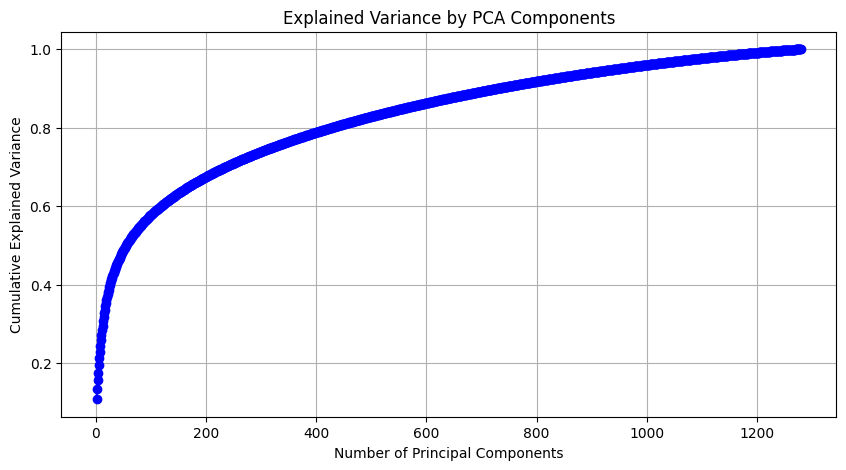

In [35]:
# Fit PCA with all components
pca = PCA(n_components=None)
pca.fit(scaled_X_train)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Select number of components where the elbow point optain
n_components_optimal = 40

# Apply PCA with optimal components
pca = PCA(n_components=n_components_optimal)

principal_components_train = pca.fit_transform(scaled_X_train)
principal_components_val = pca.transform(scaled_X_val)

In [36]:
principal_components_train

array([[ -4.39719687,  -1.4550248 ,  -5.38291022, ...,  -2.29729651,
         -1.21649718,  -2.40425371],
       [ 20.60009166,  -3.82999019,  -8.23980244, ...,   1.01221239,
          0.38326875,  -1.521545  ],
       [ -8.56723596,   3.42254453,   1.41882075, ...,   1.49028436,
         -3.45558665,  -2.78596968],
       ...,
       [ -8.4471268 ,  -1.22313291,  -1.96796062, ...,   1.10305427,
          0.56862004,   2.46211551],
       [ -9.13537511,  -1.85155456,  -3.89383484, ...,  -1.17313792,
         -1.35524997,  -1.08741425],
       [ -2.83993711, -21.29634177,   4.22069811, ...,  -1.35674413,
          0.09785885,   1.96373958]])

In [37]:
# Initialize Random Forest with class_weight='balanced'
rf_model_on_pca = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    class_weight='balanced'  # Handles the imbalance automatically
)

# Fit the model
rf_model_on_pca.fit(principal_components_train, y_train_binary)

# Make predictions
y_pred = rf_model_on_pca.predict(principal_components_val)

# Evaluate the model
print("Balanced Accuracy:", balanced_accuracy_score(y_val_binary, y_pred))
print("\nClassification Report:\n", classification_report(y_val_binary, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_binary, y_pred))

Balanced Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       212
           1       0.97      1.00      0.99      7594

    accuracy                           0.97      7806
   macro avg       0.49      0.50      0.49      7806
weighted avg       0.95      0.97      0.96      7806


Confusion Matrix:
 [[   0  212]
 [   0 7594]]


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Gained insights :
No imporvements interms of performance and generalization.

## 3.Addressing class imbalance - SMOTE

In [38]:
X = scaled_X_train
y = y_train_binary

print("Original class distribution:", Counter(y))

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X, y)
print("After SMOTE:", Counter(y_train_smote))

Original class distribution: Counter({1: 36668, 0: 526})
After SMOTE: Counter({1: 36668, 0: 36668})


In [39]:
# Initialize Random Forest with class_weight='balanced'
rf_model_balanced = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    class_weight='balanced'  # Handles the imbalance automatically
)

# Fit the model
rf_model_balanced.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred = rf_model_balanced.predict(scaled_X_val)

# Evaluate the model
print("Balanced Accuracy:", balanced_accuracy_score(y_val_binary, y_pred))
print("\nClassification Report:\n", classification_report(y_val_binary, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_binary, y_pred))

Balanced Accuracy: 0.496707927311035

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       212
           1       0.97      0.99      0.98      7594

    accuracy                           0.97      7806
   macro avg       0.49      0.50      0.49      7806
weighted avg       0.95      0.97      0.96      7806


Confusion Matrix:
 [[   0  212]
 [  50 7544]]


#### 3.1 Apply hyper parameter tuning for number of estimators and number of principle components

In [ ]:
# Define parameter ranges
n_components_list = [2, 4, 6, 8, 10]
n_estimators_list = [5, 10, 20]

best_score = 0
best_params = {}
results = []

for n_components, n_estimators in itertools.product(n_components_list, n_estimators_list):
    # Apply PCA
    pca = PCA(n_components=n_components)
    principal_components_train = pca.fit_transform(X_train_smote)
    principal_components_val = pca.transform(scaled_X_val)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=42)
    rf.fit(principal_components_train, y_train_smote)

    # Predict and evaluate on validation set
    y_pred = rf.predict(principal_components_val)
    score = balanced_accuracy_score(y_val_binary, y_pred)

    results.append((n_components, n_estimators, score))

    if score > best_score:
        best_score = score
        best_params = {
            'n_components': n_components,
            'n_estimators': n_estimators
        }

# Print best results
print("Best Balanced Accuracy Score:", best_score)
print("Best Parameters:", best_params)

# Optional: Detailed results
print("\nAll Scores:")
for n_comp, n_est, scr in results:
    print(f"n_components={n_comp}, n_estimators={n_est} --> Score={scr:.4f}")

Best Balanced Accuracy Score: 0.5253868495982429
Best Parameters: {'n_components': 4, 'n_estimators': 5}

All Scores:
n_components=2, n_estimators=5 --> Score=0.4965
n_components=2, n_estimators=10 --> Score=0.5027
n_components=2, n_estimators=20 --> Score=0.5091
n_components=4, n_estimators=5 --> Score=0.5254
n_components=4, n_estimators=10 --> Score=0.5179
n_components=4, n_estimators=20 --> Score=0.5018
n_components=6, n_estimators=5 --> Score=0.4922
n_components=6, n_estimators=10 --> Score=0.4956
n_components=6, n_estimators=20 --> Score=0.5029
n_components=8, n_estimators=5 --> Score=0.5145
n_components=8, n_estimators=10 --> Score=0.5002
n_components=8, n_estimators=20 --> Score=0.4998
n_components=10, n_estimators=5 --> Score=0.5064
n_components=10, n_estimators=10 --> Score=0.5030
n_components=10, n_estimators=20 --> Score=0.4937


In [41]:
pca_balanced = PCA(n_components=4)
principal_components_train = pca_balanced .fit_transform(X_train_smote)
principal_components_val = pca_balanced .transform(scaled_X_val)

# Initialize Random Forest with class_weight='balanced'
rf_model_on_pca_balanced = RandomForestClassifier(
    n_estimators=5,
    random_state=42,
    class_weight='balanced'  # Handles the imbalance automatically
)

# Fit the model
rf_model_on_pca_balanced.fit(principal_components_train, y_train_smote)

# Make predictions
y_pred = rf_model_on_pca_balanced.predict(principal_components_val)

# Evaluate the model
print("Balanced Accuracy:", balanced_accuracy_score(y_val_binary, y_pred))
print("\nClassification Report:\n", classification_report(y_val_binary, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_binary, y_pred))

Balanced Accuracy: 0.5286553187471739

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.23      0.06       212
           1       0.97      0.83      0.89      7594

    accuracy                           0.81      7806
   macro avg       0.51      0.53      0.48      7806
weighted avg       0.95      0.81      0.87      7806


Confusion Matrix:
 [[  49  163]
 [1320 6274]]


## 4.Consolidate the Data Mining Pipeline 

In [42]:
# Define the pipeline
model_pipeline = Pipeline(steps=[
    ('scaler', scaler),
    ('pca', pca_balanced),
    ('classifier', rf_model_on_pca_balanced)
])

y_pred = model_pipeline.predict(X_val)

# Evaluate the model
print("Balanced Accuracy:", balanced_accuracy_score(y_val_binary, y_pred))
print("\nClassification Report:\n", classification_report(y_val_binary, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_binary, y_pred))

Balanced Accuracy: 0.5286553187471739

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.23      0.06       212
           1       0.97      0.83      0.89      7594

    accuracy                           0.81      7806
   macro avg       0.51      0.53      0.48      7806
weighted avg       0.95      0.81      0.87      7806


Confusion Matrix:
 [[  49  163]
 [1320 6274]]


## 5.Generation of predictions on holdout set

In [43]:
# load holdout data
df_test = pd.read_csv('../df/df_holdout.csv')

In [44]:
df_test.head()

,Info_PepID,Info_organism_id,Info_protein_id,Info_pos,Info_AA,Info_epitope_id,Info_nPos,Info_nNeg,Info_cluster,feat_esm1b_0,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,XP_811713.1:24,5693,XP_811713.1,393,M,300310,0,1,152,0.059545,...,-0.199119,0.338599,0.120143,0.251270,-0.086993,0.325613,-0.168032,-0.077176,0.156173,0.197907
1,XP_815867.1:20,5693,XP_815867.1,323,A,317953,0,1,196,-0.184374,...,0.175379,0.510741,0.551252,0.118376,0.067356,0.107253,-0.209368,-0.399996,0.477752,0.096655
2,XP_806521.1:6,5693,XP_806521.1,63,L,337059,0,1,73,-0.106014,...,-0.011647,0.273411,0.470711,-0.185569,-0.333693,0.111798,-0.256907,-0.146225,0.425934,0.164406
3,XP_813607.1:10,5693,XP_813607.1,409,E,"277083,278444,266356","0,0,0","1,1,1",36,-0.236488,...,-0.147599,0.288514,0.559562,-0.168071,0.012875,0.013071,-0.358416,-0.427633,0.436865,0.262321
4,XP_804333.1:2,5693,XP_804333.1,79,K,"249818,376288","0,0","1,1",32,0.212856,...,0.074901,0.083372,0.552256,-0.043704,-0.299081,-0.088415,-0.340818,-0.101821,0.370127,0.193607


In [46]:
df_test_features = df_test.iloc[:, 9:]

In [47]:
df_test_features.head()

,feat_esm1b_0,feat_esm1b_1,feat_esm1b_2,feat_esm1b_3,feat_esm1b_4,feat_esm1b_5,feat_esm1b_6,feat_esm1b_7,feat_esm1b_8,feat_esm1b_9,...,feat_esm1b_1270,feat_esm1b_1271,feat_esm1b_1272,feat_esm1b_1273,feat_esm1b_1274,feat_esm1b_1275,feat_esm1b_1276,feat_esm1b_1277,feat_esm1b_1278,feat_esm1b_1279
0,0.059545,0.267323,-0.192438,-0.027794,-0.136770,0.246337,-0.333765,0.160470,-0.031245,-0.140566,...,-0.199119,0.338599,0.120143,0.251270,-0.086993,0.325613,-0.168032,-0.077176,0.156173,0.197907
1,-0.184374,0.304711,-0.011527,-0.175148,0.208011,0.079960,-0.082697,-0.026612,-0.155088,-0.013318,...,0.175379,0.510741,0.551252,0.118376,0.067356,0.107253,-0.209368,-0.399996,0.477752,0.096655
2,-0.106014,0.468285,-0.135112,0.143231,-0.255685,0.003322,-0.194076,0.253107,-0.006404,-0.077628,...,-0.011647,0.273411,0.470711,-0.185569,-0.333693,0.111798,-0.256907,-0.146225,0.425934,0.164406
3,-0.236488,0.175111,-0.084474,-0.187937,0.129934,-0.168044,-0.075363,0.018626,0.145844,-0.264499,...,-0.147599,0.288514,0.559562,-0.168071,0.012875,0.013071,-0.358416,-0.427633,0.436865,0.262321
4,0.212856,0.410976,-0.092713,-0.056089,0.149886,-0.026412,-0.151819,0.293128,-0.058251,-0.143812,...,0.074901,0.083372,0.552256,-0.043704,-0.299081,-0.088415,-0.340818,-0.101821,0.370127,0.193607


In [48]:
imputer_test = SimpleImputer(strategy='mean') 
df_test_features_no_missing_values = pd.DataFrame(imputer.fit_transform(df_test_features), columns=df_features.columns)

In [49]:
columns = df_test_features_no_missing_values.columns
df_test_features_no_outliers = df_test_features_no_missing_values.copy()
for ele in columns:
    df_test_features_tem = simple_imputation(df_test_features_no_outliers, ele)
    df_test_features_no_outliers = df_test_features_tem
    print(f"imputation complted for {ele}")

116
imputation complted for feat_esm1b_0
38
imputation complted for feat_esm1b_1
23
imputation complted for feat_esm1b_2
69
imputation complted for feat_esm1b_3
95
imputation complted for feat_esm1b_4
23
imputation complted for feat_esm1b_5
46
imputation complted for feat_esm1b_6
72
imputation complted for feat_esm1b_7
135
imputation complted for feat_esm1b_8
82
imputation complted for feat_esm1b_9
110
imputation complted for feat_esm1b_10
152
imputation complted for feat_esm1b_11
86
imputation complted for feat_esm1b_12
72
imputation complted for feat_esm1b_13
73
imputation complted for feat_esm1b_14
14
imputation complted for feat_esm1b_15
96
imputation complted for feat_esm1b_16
90
imputation complted for feat_esm1b_17
35
imputation complted for feat_esm1b_18
117
imputation complted for feat_esm1b_19
63
imputation complted for feat_esm1b_20
5
imputation complted for feat_esm1b_21
175
imputation complted for feat_esm1b_22
158
imputation complted for feat_esm1b_23
80
imputation complt

In [54]:
test_pred = model_pipeline.predict(df_test_features_no_outliers)

In [55]:
test_pred

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [56]:
test_pred_submission = pd.DataFrame(test_pred, columns= ['Class']).replace(0, -1)

In [57]:
test_pred_submission

,Class
0,1
1,1
2,1
3,1
4,1
...,...
4601,1
4602,1
4603,-1
4604,1


In [58]:
#add Info_PepID, Info_pos
test_submission = pd.concat(
    [df_test['Info_PepID'], df_test['Info_pos'], test_pred_submission],
    axis=1
)

In [59]:
test_submission.head(10)

,Info_PepID,Info_pos,Class
0,XP_811713.1:24,393,1
1,XP_815867.1:20,323,1
2,XP_806521.1:6,63,1
3,XP_813607.1:10,409,1
4,XP_804333.1:2,79,1
5,XP_817851.1:10,266,1
6,XP_820186.1:42,879,-1
7,XP_821251.1:11,215,1
8,XP_816335.1:166,3607,1
9,XP_807437.1:24,471,1


In [61]:
test_submission.to_csv('df_holdout_with_label.csv', index=False)

## 6.References

Kumar, A. (2023, November 24). PCA explained variance concepts with Python example. Vitalflux. https://vitalflux.com/pca-explained-variance-concept-python-example/

Lemaître, G., Nogueira, F., & Aridas, C. K. (n.d.). imblearn.over_sampling.SMOTE — imbalanced-learn 0.12.2 documentation. https://imbalancedlearn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (n.d.). sklearn.ensemble.RandomForestClassifier — scikit-learn 1.4.2 documentation.  https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (n.d.). sklearn.linear_model.LogisticRegression — scikit-learn 1.4.2 documentation.  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Prabhu, P. (2023, February 20). Outlier detection and removal using the IQR method. Medium. https://medium.com/@pp1222001/outlier-detection-and-removal-using-the-iqr-method-6fab2954315d